<a href="https://colab.research.google.com/github/rogeralba19/orderbook/blob/main/Datos_order_book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELDA 1: Instalación de dependencias e importaciones
# Instala python-binance y trae las herramientas base del proyecto
# ============================================================
!pip install python-binance

from binance.client import Client          # Cliente oficial para el API REST de Binance
import numpy as np                         # Arrays y operaciones numéricas
import time                                # Pausas entre requests con time.sleep()
from IPython.display import clear_output   # Limpia el output del loop en Colab


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 65 kB 1.8 MB/s 
     |████████████████████████████████| 1.1 MB 40.3 MB/s 
     |████████████████████████████████| 288 kB 51.1 MB/s 
     |████████████████████████████████| 112 kB 43.3 MB/s 
     |████████████████████████████████| 45 kB 1.4 MB/s 
     |████████████████████████████████| 144 kB 49.2 MB/s 
     |████████████████████████████████| 94 kB 1.6 MB/s 
     |████████████████████████████████| 271 kB 45.4 MB/s 
     |████████████████████████████████| 749 kB 51.7 MB/s 
  Attempting uninstall: regex
    Found existing installation: regex 2022.6.2
    Uninstalling regex-2022.6.2:
      Successfully uninstalled regex-2022.6.2


In [ ]:
# ============================================================
# CELDA 2: Autenticación con el API de Binance
# Reemplaza los strings con tus credenciales reales del API
# ============================================================
api_key    = "api_key"     # Llave pública del API de Binance
api_secret = "api_secret"  # Llave secreta del API de Binance

# Crea el cliente autenticado — todas las llamadas al exchange usan este objeto
client = Client(api_key, api_secret)


In [ ]:
# ============================================================
# CELDA 3: Recolección del order book (loop principal)
#
# Toma 300 snapshots del order book BTC/USDT con 1 segundo de pausa
# entre cada uno → ~5 minutos de datos en tiempo real.
#
# Cada snapshot tiene los 50 mejores niveles de precio de:
#   asks (órdenes de venta)   — alguien quiere venderte BTC
#   bids (órdenes de compra)  — alguien quiere comprarte BTC
#
# Estructura tras aplanar (np.reshape):
#   [precio1, cantidad1, precio2, cantidad2, ..., precio50, cantidad50]
#   → 100 elementos por snapshot
# ============================================================

cont   = 0
orderA = []  # Acumula los 300 snapshots de asks (ventas)
orderB = []  # Acumula los 300 snapshots de bids (compras)

while cont < 300:
    print(cont)  # Muestra el progreso del loop

    # Consulta el order book actual para BTC/USDT con los 50 mejores niveles
    # Respuesta del API: {'asks': [[precio, cantidad], ...], 'bids': [...]}
    book = client.get_order_book(symbol="BTCUSDT", limit=50)

    book_asks = []
    book_bids = []
    book_asks.append(book['asks'])  # 50 pares [precio, cantidad] — lado venta
    book_bids.append(book['bids'])  # 50 pares [precio, cantidad] — lado compra

    # np.reshape(..., -1) aplana [[p1,q1],[p2,q2],...] → [p1,q1,p2,q2,...]
    # Resultado: 100 números por snapshot (precios y cantidades intercalados)
    datosA = np.reshape(book_asks, -1)
    datosB = np.reshape(book_bids, -1)

    orderA.append(datosA.tolist())  # Guarda snapshot de asks como lista Python
    orderB.append(datosB.tolist())  # Guarda snapshot de bids como lista Python

    cont = cont + 1
    time.sleep(1)            # Espera 1 segundo antes del siguiente snapshot
    clear_output(wait=True)  # Borra el contador anterior para no llenar la pantalla

print(orderB)


[['19047.99000000', '0.24374000', '19047.55000000', '0.00057000', '19047.54000000', '0.30000000', '19045.05000000', '0.12357000', '19045.04000000', '0.00105000', '19045.03000000', '0.70056000', '19045.02000000', '0.00630000', '19044.75000000', '0.08542000', '19044.71000000', '0.31000000', '19044.20000000', '0.01890000', '19044.19000000', '0.00524000', '19043.25000000', '0.00208000', '19043.12000000', '0.28000000', '19042.77000000', '0.05454000', '19042.39000000', '0.08073000', '19041.55000000', '0.10000000', '19041.20000000', '0.28000000', '19040.75000000', '0.04697000', '19039.17000000', '0.68424000', '19039.15000000', '0.28000000', '19039.00000000', '1.00000000', '19038.90000000', '0.43050000', '19037.00000000', '0.42000000', '19036.98000000', '0.28000000', '19035.14000000', '2.75485000', '19035.05000000', '2.10000000', '19034.70000000', '0.00510000', '19034.69000000', '0.01400000', '19034.68000000', '0.28288000', '19034.58000000', '0.01574000', '19032.48000000', '7.36153000', '19032

In [ ]:
# ============================================================
# CELDA 4: Conversión de listas a arrays numpy
#
# Transforma los 300 snapshots en un único array 1D de floats.
# Esto permite usar slicing (0::2, 1::2) para separar precios
# de cantidades en la celda de visualización.
#
# Shape resultante: (1, 30000)  — 300 snapshots × 100 elementos
# ============================================================

orderAa = []
orderBb = []

# np.reshape([orderA], (1,-1)) apila todos los snapshots en una sola fila
# .astype(float) convierte los strings del API ("29500.00") a float64
orderAa = np.reshape([orderA], (1, -1)).astype(float)  # shape (1, 30000) — asks
orderBb = np.reshape([orderB], (1, -1)).astype(float)  # shape (1, 30000) — bids

print(type(orderAa[0]))


<class 'numpy.ndarray'>


In [ ]:
# ============================================================
# CELDA 5: Visualización 3D estática del order book en el tiempo
#
# Cada punto representa UN nivel de precio en UN momento:
#   Eje X → Precio (USDT)
#   Eje Y → Tiempo  (número de snapshot, 1 a 300)
#   Eje Z → Cantidad disponible en ese nivel (BTC)
#
# Rojo  = asks  (órdenes de venta)
# Verde = bids  (órdenes de compra)
# ============================================================

from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
import matplotlib as mpl
import numpy as np

fig = plt.figure(figsize=(40, 35))  # Figura grande para ver los 300 snapshots con claridad
ax  = fig.add_subplot(111, projection='3d')

# Eje Y (tiempo): para cada snapshot i, repite el valor i+1 exactamente 50 veces
# (una vez por cada nivel de precio del order book)
y = np.array([])
for i in range(300):
    y = np.append(y, np.ones(50) + i)  # [i+1, i+1, ..., i+1]  (50 veces)

# El array aplanado intercala precios y cantidades:
#   índices pares   (0,2,4,...) → precios
#   índices impares (1,3,5,...) → cantidades
x1 = orderAa[0][0::2]  # Precios de asks
x2 = orderBb[0][0::2]  # Precios de bids
z1 = orderAa[0][1::2]  # Cantidades de asks
z2 = orderBb[0][1::2]  # Cantidades de bids

mpl.rcParams['legend.fontsize'] = 10

# ── Escalado personalizado del cubo 3D ──────────────────────────────────────
# Sin esto matplotlib fuerza proporciones iguales y el gráfico queda aplastado.
# Multiplicamos la matriz de proyección estándar por una diagonal de escala.
x_scale = 32
y_scale = 32
z_scale = 25

scale       = np.diag([x_scale, y_scale, z_scale, 1.0])
scale       = scale * (1.0 / scale.max())
scale[3, 3] = 1.0

def short_proj():
    # Proyección escalada: sobreescribe el método interno de Axes3D
    return np.dot(Axes3D.get_proj(ax), scale)

ax.get_proj = short_proj  # Inyecta la proyección escalada en el objeto de ejes
# ────────────────────────────────────────────────────────────────────────────

# Dibuja asks (rojo) y bids (verde) en el espacio Precio × Tiempo × Cantidad
for c, m, xs, zs in [('r', 'o', x1, z1), ('g', 'o', x2, z2)]:
    ax.scatter(xs, y, zs, c=c, marker=m)

ax.set_xlabel('Precio (USDT)')
ax.set_ylabel('Tiempo (snapshot #)')
ax.set_zlabel('Cantidad (BTC)')

plt.show()


In [ ]:
# ============================================================
# CELDA 6: Montar Google Drive (opcional)
# Permite leer/guardar archivos directamente desde tu Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ============================================================
# CELDA 7: Importaciones para animación 3D
# matplotlib.animation permite crear videos frame-a-frame
# y exportarlos como MP4 (ffmpeg) o GIF (imagemagick)
# ============================================================
import numpy as np
from numpy.random import normal as normal
print('numpy: ' + np.version.full_version)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation  # Motor de animación de matplotlib
import matplotlib
print('matplotlib: ' + matplotlib.__version__)


numpy: 1.21.6
matplotlib: 3.2.2


In [ ]:
# ============================================================
# CELDA 8: Datos sintéticos para la animación
#
# Genera 58 frames de nubes de puntos 3D centradas en (50, 50, 50).
# La desviación estándar aumenta con cada frame → la nube se expande.
# Son datos de prueba para demostrar el mecanismo de animación.
# ============================================================

nfr = 30   # Frames visibles en la animación
fps = 10   # Frames por segundo → duración ≈ 3 segundos

xs, ys, zs = [], [], []

# ss = [1.0, 1.5, 2.0, ..., 29.5]  — desviación creciente en cada paso
ss = np.arange(1, nfr, 0.5)

for s in ss:
    # 200 puntos normales con media=50 y desviación=s
    # A mayor s los puntos están más dispersos alrededor del centro
    xs.append(normal(50, s, 200))
    ys.append(normal(50, s, 200))
    zs.append(normal(50, s, 200))


<class 'list'>


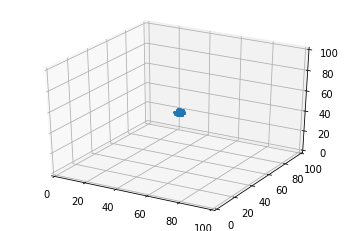

In [ ]:
# ============================================================
# CELDA 9: Construcción de la animación con FuncAnimation
#
# FuncAnimation llama a update() una vez por frame, pasándole
# el índice del frame y los datos pre-generados.
# update() desplaza los puntos del scatter a su nueva posición.
# ============================================================

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

# Scatter vacío — sus datos se reemplazan en cada frame por update()
sct, = ax.plot([], [], [], "o", markersize=2)

def update(ifrm, xa, ya, za):
    # ifrm: índice del frame actual (0, 1, 2, ...)
    # Actualiza X/Y en el plano y luego Z (profundidad)
    sct.set_data(xa[ifrm], ya[ifrm])
    sct.set_3d_properties(za[ifrm])

# Límites fijos para que los ejes no salten entre frames
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_zlim(0, 100)

# interval = ms entre frames; fargs pasa los datos a update()
ani = animation.FuncAnimation(fig, update, nfr, fargs=(xs, ys, zs), interval=1000/fps)

print(type(xs))


In [ ]:
# ============================================================
# CELDA 10: Exportar la animación a MP4
# Requiere ffmpeg instalado (disponible por defecto en Colab)
# Descomenta la segunda línea para exportar como GIF
# ============================================================

fn = 'plot_3d_scatter_funcanimation'
ani.save(fn + '.mp4', writer='ffmpeg', fps=fps)
# ani.save(fn + '.gif', writer='imagemagick', fps=fps)  # Alternativa GIF
